# Band width vs parameter count (bkg_penalty ON)

1 eV, `bkg_penalty=True`. Sweep the number of flux parameters
`n` (= CRmat columns via `intervals`) and look at how the confidence-band
width changes. The data bin count `m = 29` is fixed, so smaller `n` means
less underdetermination.

Band width is measured at a few fixed physical energies (the index nearest
each target energy), for both scenarios **a (No Bkg)** and **b (Exp Bkg)**,
at 1σ (0.678) and 2σ (0.954).

Data produced by `run_param_scan.py` → `param_scan_results.json`.
Run this notebook from `1eV/` or from `1eV/param_scan_bkgpen/`.


In [22]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# locate the results file whether run from 1eV/ or from the scan folder
CANDS = ['param_scan_bkgpen/param_scan_results.json', 'param_scan_results.json']
PATH = next((p for p in CANDS if os.path.exists(p)), None)
assert PATH, f'param_scan_results.json not found (looked in {CANDS})'
df = pd.DataFrame(json.load(open(PATH)))
NORM = 1e12
SCEN_LABEL = {'a': 'No Bkg', 'b': 'Exp Bkg'}
df['scenario_label'] = df['scenario'].map(lambda s: SCEN_LABEL.get(s, f'bkg {s}'))
df['width_n'] = df['width'] / NORM
print(f'loaded {len(df)} records from {PATH}')
print('n      :', sorted(df.n.unique()))
print('E targ :', sorted(df.target_E.unique()))
print('levels :', sorted(df.level.unique()))
df.head()


loaded 108 records from param_scan_results.json
n      : [np.int64(10), np.int64(20), np.int64(31), np.int64(60), np.int64(80), np.int64(100), np.int64(120), np.int64(140), np.int64(160)]
E targ : [np.float64(0.4), np.float64(0.6), np.float64(0.9)]
levels : [np.float64(0.678), np.float64(0.954)]


,scenario,n,target_E,idx,E,level,lower,upper,width,best_fit,bkg_penalty,scenario_label,width_n
0,a,10,0.4,1,0.382222,0.678,9.267324e+11,1.194019e+12,2.672870e+11,1.065248e+12,True,No Bkg,0.267287
1,a,10,0.4,1,0.382222,0.954,8.373972e+11,1.288334e+12,4.509368e+11,1.065248e+12,True,No Bkg,0.450937
2,a,10,0.6,2,0.584444,0.678,7.648142e+11,9.854010e+11,2.205868e+11,8.791287e+11,True,No Bkg,0.220587
3,a,10,0.6,2,0.584444,0.954,7.088247e+11,1.063237e+12,3.544123e+11,8.791287e+11,True,No Bkg,0.354412
4,a,10,0.9,4,0.988889,0.678,4.534212e+11,6.465195e+11,1.930984e+11,5.482892e+11,True,No Bkg,0.193098


In [23]:
# width [1e12 cm^-2 s^-1] as a table: rows = (scenario, target_E, level), cols = n
piv = df.pivot_table(index=['scenario_label', 'target_E', 'level'],
                     columns='n', values='width_n')
piv.round(4)


n                                 10      20      31      60      80      100  \
scenario_label target_E level                                                   
Exp Bkg        0.4      0.678  0.3752  0.5128  0.5236  0.5775  0.5983  0.5761   
                        0.954  0.5792  0.8075  0.7706  0.8778  0.8763  0.9179   
               0.6      0.678  0.2837  0.4192  0.4176  0.4938  0.5038  0.5065   
                        0.954  0.4903  0.6277  0.6145  0.6638  0.6773  0.6959   
               0.9      0.678  0.2491  0.3502  0.4015  0.4375  0.4286  0.4340   
                        0.954  0.3825  0.5089  0.5568  0.5559  0.6009  0.5608   
No Bkg         0.4      0.678  0.2673  0.3978  0.4332  0.4602  0.4824  0.4821   
                        0.954  0.4509  0.6300  0.5993  0.6962  0.6568  0.6946   
               0.6      0.678  0.2206  0.3251  0.3549  0.4023  0.4106  0.4126   
                        0.954  0.3544  0.4846  0.5074  0.5399  0.5676  0.5400   
               0.9      0.678  0.1931  0.3092  0.3565  0.3825  0.3957  0.3908   
                        0.954  0.3160  0.4305  0.4684  0.5032  0.5156  0.5092   

n                                 120     140     160  
scenario_label target_E level                          
Exp Bkg        0.4      0.678  0.5758  0.5977  0.5759  
                        0.954  0.9608  0.9176  0.9609  
               0.6      0.678  0.5072  0.5064  0.5232  
                        0.954  0.6818  0.6808  0.6955  
               0.9      0.678  0.4292  0.4250  0.4501  
                        0.954  0.6019  0.5959  0.6098  
No Bkg         0.4      0.678  0.4942  0.4819  0.4943  
                        0.954  0.7333  0.6943  0.7335  
               0.6      0.678  0.4133  0.4126  0.4303  
                        0.954  0.5714  0.5703  0.5701  
               0.9      0.678  0.3752  0.3924  0.4069  
                        0.954  0.5263  0.5113  0.5254

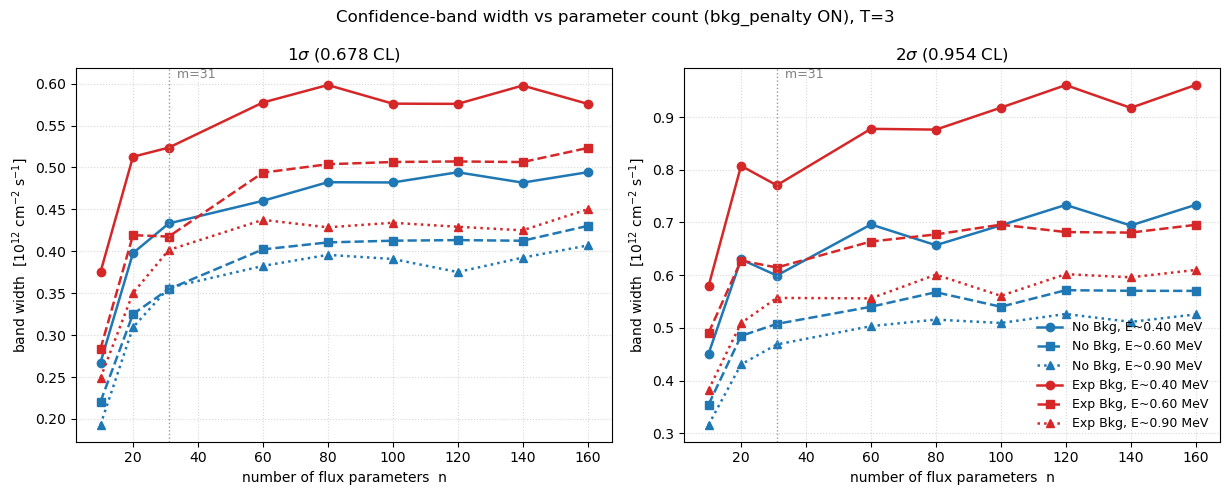

saved width_vs_n.pdf


In [30]:
# band width vs n: one subplot per confidence level
levels  = sorted(df.level.unique())
scens   = sorted(df.scenario.unique())
targets = sorted(df.target_E.unique())
scen_color = {s: c for s, c in zip(scens, ['C0', 'C3', 'C2', 'C1'])}
targ_ls    = {E: ls for E, ls in zip(targets, ['-', '--', ':', '-.'])}
targ_mk    = {E: mk for E, mk in zip(targets, ['o', 's', '^', 'D'])}

fig, axes = plt.subplots(1, len(levels), figsize=(6.2 * len(levels), 5),
                         squeeze=False)
for ax, lv in zip(axes[0], levels):
    for s in scens:
        for E in targets:
            sub = df[(df.scenario == s) & (df.target_E == E) &
                     (df.level == lv)].sort_values('n')
            if sub.empty:
                continue
            ax.plot(sub.n, sub.width_n, color=scen_color[s],
                    ls=targ_ls[E], marker=targ_mk[E], lw=1.8, ms=6,
                    label=f'{SCEN_LABEL.get(s, s)}, E~{E:.2f} MeV')
    nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
    ax.set_title(rf'{nsig}$\sigma$ ({lv:.3f} CL)')
    ax.set_xlabel('number of flux parameters  n')
    ax.set_ylabel(r'band width  [$10^{12}$ cm$^{-2}$ s$^{-1}$]')
    ax.axvline(31, color='0.6', ls=':', lw=1)      # data bin count m = 31
    ax.text(31, ax.get_ylim()[1], '  m=31', color='0.5', va='top', fontsize=9)
    ax.grid(ls=':', alpha=0.5)
ax.legend(frameon=False, fontsize=9)
fig.suptitle('Confidence-band width vs parameter count (bkg_penalty ON), T=3')
fig.tight_layout()
fig.savefig('param_scan_bkgpen/width_vs_n.pdf' if os.path.isdir('param_scan_bkgpen')
            else 'width_vs_n.pdf')
plt.show()
print('saved width_vs_n.pdf')


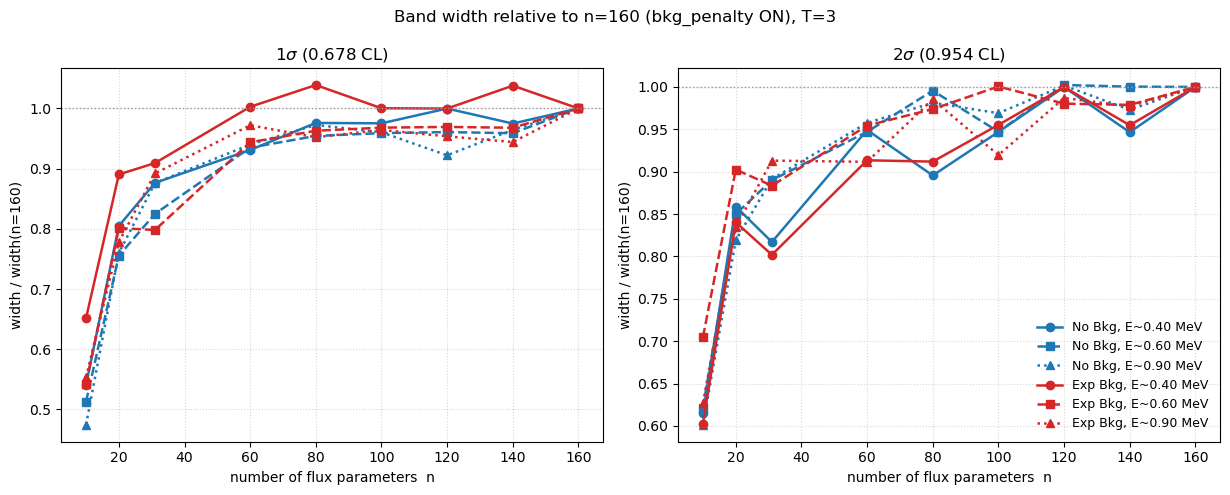

In [31]:
# same, normalised to the largest n (relative change as parameters drop)
n_ref = df.n.max()
fig, axes = plt.subplots(1, len(levels), figsize=(6.2 * len(levels), 5),
                         squeeze=False)
for ax, lv in zip(axes[0], levels):
    for s in scens:
        for E in targets:
            sub = df[(df.scenario == s) & (df.target_E == E) &
                     (df.level == lv)].sort_values('n')
            if sub.empty:
                continue
            ref = sub[sub.n == n_ref]['width'].values
            if not len(ref) or ref[0] == 0:
                continue
            ax.plot(sub.n, sub['width'] / ref[0], color=scen_color[s],
                    ls=targ_ls[E], marker=targ_mk[E], lw=1.8, ms=6,
                    label=f'{SCEN_LABEL.get(s, s)}, E~{E:.2f} MeV')
    nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
    ax.set_title(rf'{nsig}$\sigma$ ({lv:.3f} CL)')
    ax.set_xlabel('number of flux parameters  n')
    ax.set_ylabel(f'width / width(n={n_ref})')
    ax.axhline(1.0, color='0.6', ls=':', lw=1)
    ax.grid(ls=':', alpha=0.5)
ax.legend(frameon=False, fontsize=9)
fig.suptitle(f'Band width relative to n={n_ref} (bkg_penalty ON), T=3')
fig.tight_layout()
plt.show()


In [26]:
# asymmetric deviations from best-fit, per energy
df['err_up'] = (df['upper'] - df['best_fit']) / NORM   # upper band - best-fit
df['err_lo'] = (df['best_fit'] - df['lower']) / NORM   # best-fit - lower band

piv = df.pivot_table(index=['scenario_label', 'target_E', 'level'], columns='n',
                     values=['err_up', 'err_lo'])
piv = piv.swaplevel(0, 1, axis=1).sort_index(axis=1)   # group by n, then side
print('upper (hi-bf) / lower (bf-lo) deviation  [1e12 cm^-2 s^-1]:')
piv.round(4)


upper (hi-bf) / lower (bf-lo) deviation  [1e12 cm^-2 s^-1]:


n                                 10              20              31           \
                               err_lo  err_up  err_lo  err_up  err_lo  err_up   
scenario_label target_E level                                                   
Exp Bkg        0.4      0.678  0.1843  0.1909  0.2414  0.2714  0.2304  0.2933   
                        0.954  0.2892  0.2901  0.3470  0.4605  0.3311  0.4395   
               0.6      0.678  0.1521  0.1316  0.1974  0.2219  0.2057  0.2118   
                        0.954  0.2222  0.2681  0.2837  0.3440  0.2861  0.3284   
               0.9      0.678  0.1173  0.1318  0.1706  0.1796  0.2016  0.1999   
                        0.954  0.1781  0.2044  0.2474  0.2616  0.2656  0.2912   
No Bkg         0.4      0.678  0.1385  0.1288  0.1954  0.2024  0.2082  0.2250   
                        0.954  0.2279  0.2231  0.2855  0.3445  0.2716  0.3277   
               0.6      0.678  0.1143  0.1063  0.1597  0.1654  0.1705  0.1844   
                        0.954  0.1703  0.1841  0.2333  0.2513  0.2390  0.2685   
               0.9      0.678  0.0949  0.0982  0.1489  0.1604  0.1780  0.1785   
                        0.954  0.1488  0.1672  0.2109  0.2196  0.2240  0.2444   

n                                 60              80              100          \
                               err_lo  err_up  err_lo  err_up  err_lo  err_up   
scenario_label target_E level                                                   
Exp Bkg        0.4      0.678  0.3568  0.2207  0.3780  0.2203  0.3560  0.2201   
                        0.954  0.4609  0.4169  0.4601  0.4161  0.4598  0.4581   
               0.6      0.678  0.2016  0.2922  0.2057  0.2981  0.1847  0.3218   
                        0.954  0.2804  0.3834  0.2861  0.3912  0.2804  0.4155   
               0.9      0.678  0.2037  0.2338  0.2099  0.2187  0.2021  0.2320   
                        0.954  0.2541  0.3018  0.2899  0.3110  0.2613  0.2994   
No Bkg         0.4      0.678  0.3113  0.1489  0.3338  0.1486  0.3335  0.1485   
                        0.954  0.4000  0.2962  0.3993  0.2575  0.3991  0.2955   
               0.6      0.678  0.1672  0.2350  0.1707  0.2399  0.1494  0.2633   
                        0.954  0.2182  0.3218  0.2392  0.3284  0.2182  0.3218   
               0.9      0.678  0.1702  0.2123  0.1987  0.1971  0.1802  0.2106   
                        0.954  0.2246  0.2786  0.2519  0.2637  0.2328  0.2764   

n                                 120             140             160          
                               err_lo  err_up  err_lo  err_up  err_lo  err_up  
scenario_label target_E level                                                  
Exp Bkg        0.4      0.678  0.3558  0.2200  0.3776  0.2201  0.3558  0.2201  
                        0.954  0.4596  0.5012  0.4596  0.4579  0.4597  0.5012  
               0.6      0.678  0.2071  0.3001  0.1846  0.3218  0.2015  0.3217  
                        0.954  0.2880  0.3938  0.2654  0.4154  0.2802  0.4152  
               0.9      0.678  0.2102  0.2190  0.2081  0.2169  0.2314  0.2187  
                        0.954  0.2904  0.3115  0.2875  0.3084  0.2988  0.3110  
No Bkg         0.4      0.678  0.3104  0.1838  0.3334  0.1485  0.3105  0.1838  
                        0.954  0.3989  0.3344  0.3989  0.2954  0.3990  0.3345  
               0.6      0.678  0.1718  0.2415  0.1493  0.2632  0.1671  0.2631  
                        0.954  0.2408  0.3307  0.2181  0.3522  0.2181  0.3520  
               0.9      0.678  0.1990  0.1762  0.1970  0.1954  0.2099  0.1971  
                        0.954  0.2622  0.2641  0.2498  0.2615  0.2618  0.2637

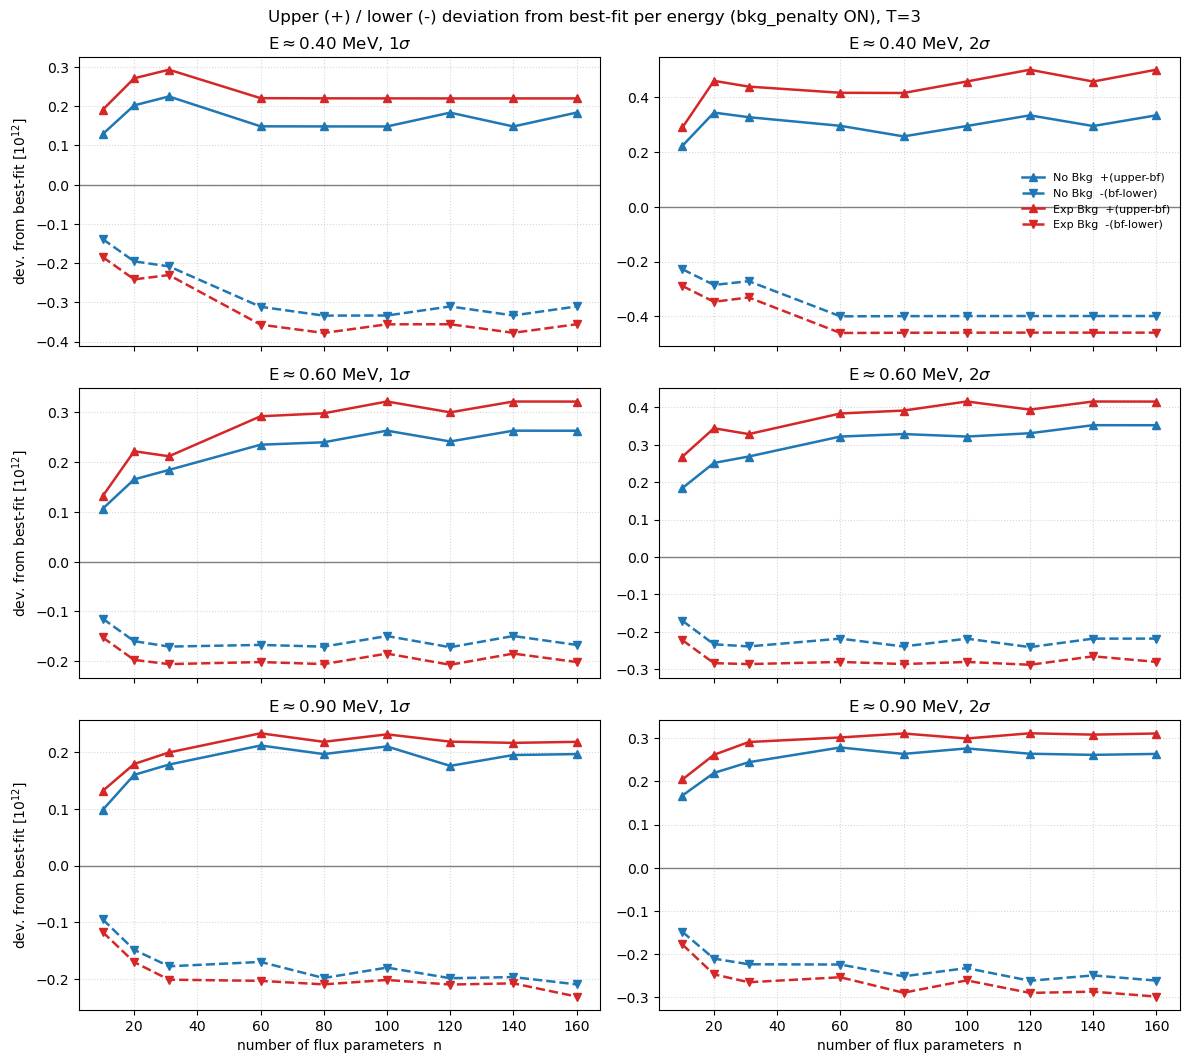

saved dev_from_bestfit_vs_n.pdf


In [27]:
# upper (+, hi-bf) and lower (-, bf-lo) deviation vs n, faceted by energy x level
levels  = sorted(df.level.unique())
targets = sorted(df.target_E.unique())
scens   = sorted(df.scenario.unique())
scen_color = {s: c for s, c in zip(scens, ['C0', 'C3', 'C2', 'C1'])}

fig, axes = plt.subplots(len(targets), len(levels),
                         figsize=(6.0 * len(levels), 3.6 * len(targets)),
                         squeeze=False, sharex=True)
for ri, E in enumerate(targets):
    for ci, lv in enumerate(levels):
        ax = axes[ri][ci]
        for s in scens:
            sub = df[(df.scenario == s) & (df.target_E == E) &
                     (df.level == lv)].sort_values('n')
            if sub.empty:
                continue
            c = scen_color[s]
            ax.plot(sub.n,  sub.err_up, color=c, ls='-',  marker='^', lw=1.8,
                    ms=6, label=f'{SCEN_LABEL.get(s, s)}  +(upper-bf)')
            ax.plot(sub.n, -sub.err_lo, color=c, ls='--', marker='v', lw=1.8,
                    ms=6, label=f'{SCEN_LABEL.get(s, s)}  -(bf-lower)')
        ax.axhline(0, color='0.5', lw=1)               # best-fit reference
        nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
        ax.set_title(rf'E$\approx${E:.2f} MeV, {nsig}$\sigma$')
        ax.grid(ls=':', alpha=0.5)
        if ci == 0:
            ax.set_ylabel(r'dev. from best-fit [$10^{12}$]')
        if ri == len(targets) - 1:
            ax.set_xlabel('number of flux parameters  n')
axes[0][-1].legend(frameon=False, fontsize=8)
fig.suptitle('Upper (+) / lower (-) deviation from best-fit per energy '
             '(bkg_penalty ON), T=3')
fig.tight_layout()
fig.savefig('param_scan_bkgpen/dev_from_bestfit_vs_n.pdf'
            if os.path.isdir('param_scan_bkgpen') else 'dev_from_bestfit_vs_n.pdf')
plt.show()
print('saved dev_from_bestfit_vs_n.pdf')


In [28]:
# 2σ - 1σ gap on each side, per energy:
#   upper = hi(2σ) - hi(1σ) = err_up(2σ) - err_up(1σ)
#   lower = lo(1σ) - lo(2σ) = err_lo(2σ) - err_lo(1σ)   (outward extent of 2σ)
df['err_up'] = (df['upper'] - df['best_fit']) / NORM
df['err_lo'] = (df['best_fit'] - df['lower']) / NORM
L1, L2 = sorted(df.level.unique())          # 1σ, 2σ

g = df.pivot_table(index=['scenario', 'scenario_label', 'target_E', 'n'],
                   columns='level', values=['err_up', 'err_lo'])
gap = pd.DataFrame({
    'gap_up': g[('err_up', L2)] - g[('err_up', L1)],
    'gap_lo': g[('err_lo', L2)] - g[('err_lo', L1)],
}).reset_index()

piv = (gap.pivot_table(index=['scenario_label', 'target_E'], columns='n',
                       values=['gap_up', 'gap_lo'])
          .swaplevel(0, 1, axis=1).sort_index(axis=1))
print(f'2sigma - 1sigma gap  [1e12 cm^-2 s^-1]   (L1={L1}, L2={L2})')
print('  gap_up = hi(2s) - hi(1s),   gap_lo = lo(1s) - lo(2s)')
piv.round(4)


2sigma - 1sigma gap  [1e12 cm^-2 s^-1]   (L1=0.678, L2=0.954)
  gap_up = hi(2s) - hi(1s),   gap_lo = lo(1s) - lo(2s)


n                           10              20              31           \
                         gap_lo  gap_up  gap_lo  gap_up  gap_lo  gap_up   
scenario_label target_E                                                   
Exp Bkg        0.4       0.1048  0.0992  0.1056  0.1891  0.1008  0.1462   
               0.6       0.0701  0.1365  0.0863  0.1221  0.0803  0.1166   
               0.9       0.0608  0.0726  0.0768  0.0820  0.0640  0.0913   
No Bkg         0.4       0.0893  0.0943  0.0900  0.1421  0.0634  0.1027   
               0.6       0.0560  0.0778  0.0736  0.0860  0.0684  0.0841   
               0.9       0.0540  0.0690  0.0621  0.0592  0.0460  0.0659   

n                           60              80              100          \
                         gap_lo  gap_up  gap_lo  gap_up  gap_lo  gap_up   
scenario_label target_E                                                   
Exp Bkg        0.4       0.1041  0.1962  0.0821  0.1959  0.1039  0.2379   
               0.6       0.0787  0.0913  0.0803  0.0931  0.0957  0.0936   
               0.9       0.0504  0.0680  0.0801  0.0923  0.0593  0.0675   
No Bkg         0.4       0.0887  0.1473  0.0656  0.1089  0.0655  0.1469   
               0.6       0.0509  0.0867  0.0685  0.0885  0.0688  0.0586   
               0.9       0.0544  0.0663  0.0533  0.0666  0.0526  0.0658   

n                           120             140             160          
                         gap_lo  gap_up  gap_lo  gap_up  gap_lo  gap_up  
scenario_label target_E                                                  
Exp Bkg        0.4       0.1038  0.2811  0.0820  0.2378  0.1038  0.2811  
               0.6       0.0809  0.0937  0.0808  0.0936  0.0787  0.0936  
               0.9       0.0802  0.0924  0.0794  0.0915  0.0674  0.0923  
No Bkg         0.4       0.0885  0.1506  0.0655  0.1469  0.0885  0.1507  
               0.6       0.0689  0.0891  0.0688  0.0890  0.0509  0.0889  
               0.9       0.0632  0.0878  0.0528  0.0661  0.0519  0.0666

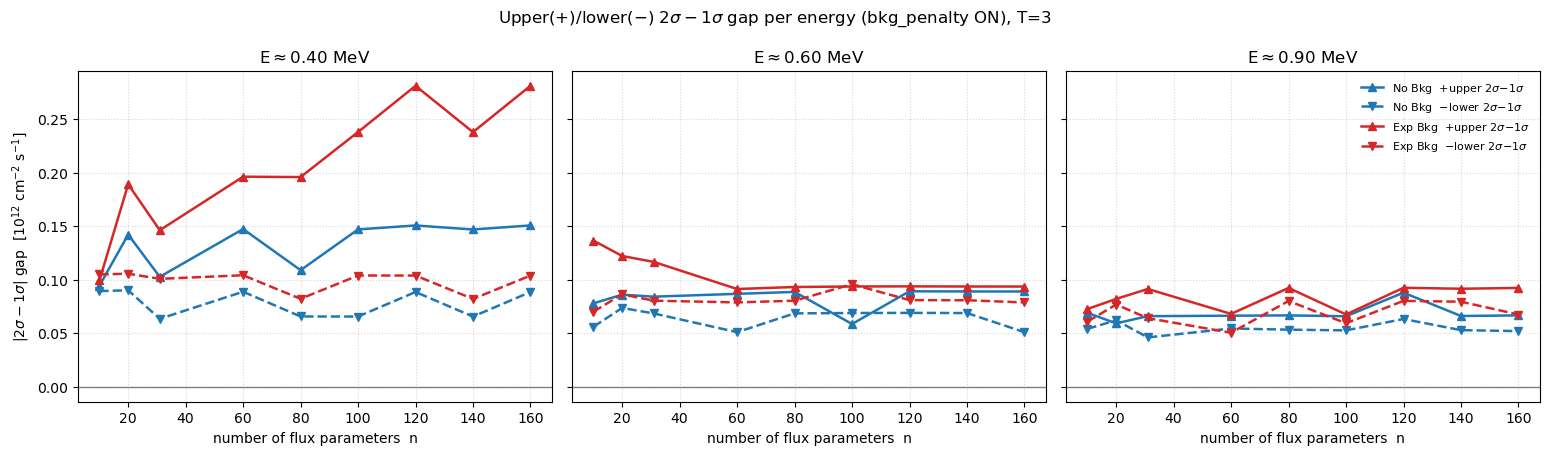

saved gap_2s_1s_vs_n.pdf


In [29]:
# 2σ-1σ gap vs n, faceted by energy: upper (+) and lower (-, drawn downward)
targets = sorted(df.target_E.unique())
scens   = sorted(df.scenario.unique())
scen_color = {s: c for s, c in zip(scens, ['C0', 'C3', 'C2', 'C1'])}

fig, axes = plt.subplots(1, len(targets), figsize=(5.2 * len(targets), 4.6),
                         squeeze=False, sharey=True)
for ci, E in enumerate(targets):
    ax = axes[0][ci]
    for s in scens:
        sub = gap[(gap.scenario == s) & (gap.target_E == E)].sort_values('n')
        if sub.empty:
            continue
        c = scen_color[s]
        ax.plot(sub.n,  sub.gap_up, color=c, ls='-',  marker='^', lw=1.8, ms=6,
                label=rf'{SCEN_LABEL.get(s, s)}  $+$upper $2\sigma\!-\!1\sigma$')
        ax.plot(sub.n, sub.gap_lo, color=c, ls='--', marker='v', lw=1.8, ms=6,
                label=rf'{SCEN_LABEL.get(s, s)}  $-$lower $2\sigma\!-\!1\sigma$')
    ax.axhline(0, color='0.5', lw=1)
    ax.set_title(rf'E$\approx${E:.2f} MeV')
    ax.set_xlabel('number of flux parameters  n')
    ax.grid(ls=':', alpha=0.5)
axes[0][0].set_ylabel(r'|$2\sigma-1\sigma$| gap  [$10^{12}$ cm$^{-2}$ s$^{-1}$]')
axes[0][-1].legend(frameon=False, fontsize=8)
fig.suptitle(r'Upper($+$)/lower($-$) $2\sigma-1\sigma$ gap per energy '
             '(bkg_penalty ON), T=3')
fig.tight_layout()
fig.savefig('param_scan_bkgpen/gap_2s_1s_vs_n.pdf'
            if os.path.isdir('param_scan_bkgpen') else 'gap_2s_1s_vs_n.pdf')
plt.show()
print('saved gap_2s_1s_vs_n.pdf')
